## Experiment 1
This baseline uses a single hidden layer with a sigmoid activation and a 64-unit bottleneck. It establishes the reference reconstruction performance for the MNIST autoencoder.

Epoch 1/100, MSE: 0.38941267960599557, Validation MSE: 0.13526056611793177
Epoch 2/100, MSE: 0.13495062750169698, Validation MSE: 0.12510026389512008
Epoch 3/100, MSE: 0.12484813868690973, Validation MSE: 0.12525164335562197
Epoch 4/100, MSE: 0.1250122657833446, Validation MSE: 0.12591282212159766
Epoch 5/100, MSE: 0.12552675252078327, Validation MSE: 0.1234272972445242
Epoch 6/100, MSE: 0.12312774860109425, Validation MSE: 0.12413272745396432
Epoch 7/100, MSE: 0.12381996550174577, Validation MSE: 0.12495040798382505
Epoch 8/100, MSE: 0.12465250631353905, Validation MSE: 0.125069555022078
Epoch 9/100, MSE: 0.12477821663985021, Validation MSE: 0.1243453796104074
Epoch 10/100, MSE: 0.12402847367027867, Validation MSE: 0.12390094560292157
Epoch 11/100, MSE: 0.12359185019010431, Validation MSE: 0.12389393608969228
Epoch 12/100, MSE: 0.12360106753578466, Validation MSE: 0.12332763665181184
Epoch 13/100, MSE: 0.12305278275634698, Validation MSE: 0.12352626563082418
Epoch 14/100, MSE: 0.12327

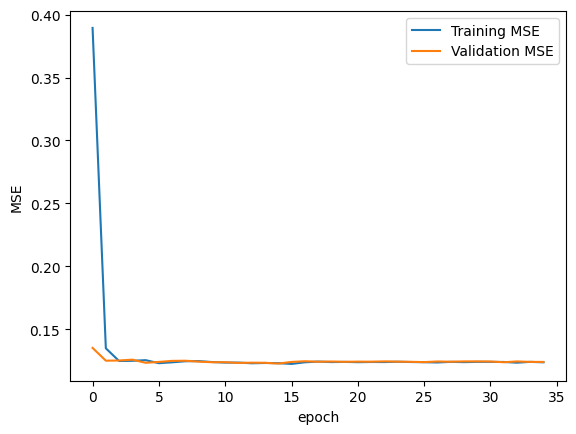

MSE Test: 0.12453918233285051


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# sigmoid derivative function
def sigmoid_derivative(x):
    return x * (1 - x)

# Autoencoder network definition
class Autoencoder:
    def __init__(self, input_size, hid_size):
        self.input_size = input_size
        self.hid_size = hid_size
        self.w1 = np.random.randn(self.input_size, self.hid_size)
        self.b1 = np.zeros((1, self.hid_size))
        self.w2 = np.random.randn(self.hid_size, self.input_size)
        self.b2 = np.zeros((1, self.input_size))
        self.best_validation_loss = float('inf')
        self.tolerance_counter = 0

    # network training process
    def train(self, X, learning_rate, epoch, valid_data, epsilon=1e-4, tolerance=20):
        mse_train_err = []
        mse_val_err = []

        for epoch in range(epoch):
            # Forward
            input_hid_layer = np.dot(X, self.w1) + self.b1
            output_hid_layer = sigmoid(input_hid_layer)
            output_layer_in = np.dot(output_hid_layer, self.w2) + self.b2
            output_layer_out = sigmoid(output_layer_in)

            # backpropagation
            loss = X - output_layer_out
            mse = np.mean(np.square(loss))
            mse_train_err.append(mse)

            d_output = loss * sigmoid_derivative(output_layer_out)
            d_hidden_layer = d_output.dot(self.w2.T) * sigmoid_derivative(output_hid_layer)

            self.w2 += output_hid_layer.T.dot(d_output) * learning_rate
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
            self.w1 += X.T.dot(d_hidden_layer) * learning_rate
            self.b1 += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

            # calculate validation error
            validation_loss = self.validate(valid_data)
            mse_val_err.append(validation_loss)

            # Check for convergence
            if validation_loss < self.best_validation_loss - epsilon:
                self.best_validation_loss = validation_loss
                self.tolerance_counter = 0
            else:
                self.tolerance_counter += 1

            if self.tolerance_counter >= tolerance:
                print(f'\nThe model has reached convergence at epoch {epoch + 1}.')
                break

            print(f'Epoch {epoch + 1}/100, MSE: {mse}, Validation MSE: {validation_loss}')

        return mse_train_err, mse_val_err

    # reconstruction evaluation function for test data
    def validate(self, X):
        input_hid_layer = np.dot(X, self.w1) + self.b1
        output_hid_layer = sigmoid(input_hid_layer)
        output_layer_in = np.dot(output_hid_layer, self.w2) + self.b2
        output_layer_out = sigmoid(output_layer_in)
        loss = X - output_layer_out
        mse = np.mean(np.square(loss))
        return mse

# load MNIST data
(train_images, _), (test_images, _) = tf.keras.datasets.mnist.load_data()

train_data = train_images.reshape(train_images.shape[0], -1) / 255.0
test_data = test_images.reshape(test_images.shape[0], -1) / 255.0

# create validation data
valid_data = train_data[:10000]
train_data = train_data[10000:]

# create autoencoder network
input_size = 784
hid_size = 64
learning_rate = 0.001
epoch = 100

autoencoder = Autoencoder(input_size, hid_size)

# train the network
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data)

# training and validation loss plot
plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

# evaluate the network on test data
mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')


## Experiment 2
This version keeps the same sigmoid setup as the baseline but increases the hidden dimension to 128 to observe whether a wider bottleneck improves reconstruction quality.

Epoch 1/100, MSE: 0.4287498475952971, Validation MSE: 0.14040995429907732
Epoch 2/100, MSE: 0.1402506279887163, Validation MSE: 0.1281044162231165
Epoch 3/100, MSE: 0.12780542482022234, Validation MSE: 0.1286492140647437
Epoch 4/100, MSE: 0.12826132661896714, Validation MSE: 0.1270858359455878
Epoch 5/100, MSE: 0.12671690219575116, Validation MSE: 0.12971373606317332
Epoch 6/100, MSE: 0.12923610880243722, Validation MSE: 0.12990796549140343
Epoch 7/100, MSE: 0.12941712448528775, Validation MSE: 0.1298997793217497
Epoch 8/100, MSE: 0.12937419925144172, Validation MSE: 0.13047668452186595
Epoch 9/100, MSE: 0.12992668021312992, Validation MSE: 0.12783933128111316
Epoch 10/100, MSE: 0.12731359907928247, Validation MSE: 0.1284703258270313
Epoch 11/100, MSE: 0.12800761575417688, Validation MSE: 0.12647219116237834
Epoch 12/100, MSE: 0.12601311250743463, Validation MSE: 0.12681811139165758
Epoch 13/100, MSE: 0.1263731083729789, Validation MSE: 0.12719876171993785
Epoch 14/100, MSE: 0.12677744

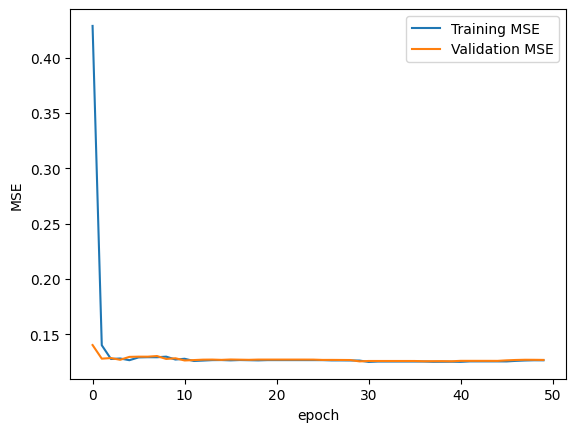

MSE Test: 0.1269403840909578


In [ ]:
# Reuse the shared sigmoid setup from Experiment 1 and only change the hidden size.
input_size = 784
hid_size = 128
learning_rate = 0.001
epoch = 100

autoencoder = Autoencoder(input_size, hid_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data)

plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Experiment 3
This configuration uses a 3-layer sigmoid autoencoder to test whether deeper hidden representations help capture more complex structure in the digits.

Epoch 1/100, MSE: 0.4315465040772567, Validation MSE: 0.22362641697629748
Epoch 2/100, MSE: 0.22345654959440175, Validation MSE: 0.19927966644575096


<ipython-input-26-bc56900e2fdc>:7: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Epoch 3/100, MSE: 0.1989163318342296, Validation MSE: 0.18788232742342714
Epoch 4/100, MSE: 0.18743586973077256, Validation MSE: 0.1858604636435573
Epoch 5/100, MSE: 0.18532171530497696, Validation MSE: 0.1847022950461015
Epoch 6/100, MSE: 0.18416145121759792, Validation MSE: 0.18263524322788394
Epoch 7/100, MSE: 0.18221379502345314, Validation MSE: 0.18122734663348986
Epoch 8/100, MSE: 0.1808219214580391, Validation MSE: 0.18095613827409984
Epoch 9/100, MSE: 0.18055386903522233, Validation MSE: 0.1786858541614003
Epoch 10/100, MSE: 0.17827913948389046, Validation MSE: 0.17923192896509502
Epoch 11/100, MSE: 0.17881209567306974, Validation MSE: 0.17835393406223263
Epoch 12/100, MSE: 0.1779436285511518, Validation MSE: 0.17816899109872905
Epoch 13/100, MSE: 0.1777579391346797, Validation MSE: 0.1791946641121004
Epoch 14/100, MSE: 0.17876892836493816, Validation MSE: 0.17818408344741923
Epoch 15/100, MSE: 0.17776987367334496, Validation MSE: 0.17672553122173523
Epoch 16/100, MSE: 0.176303

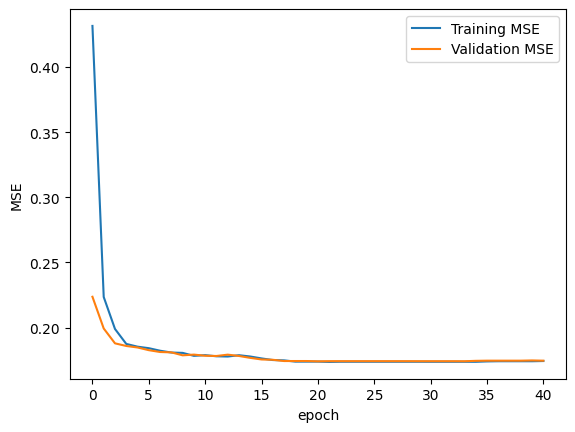

MSE Test: 0.1744317873755693


In [ ]:
# 3-layer sigmoid autoencoder: keep the unique deeper architecture and only reuse the shared sigmoid helpers.
class Autoencoder:
    def __init__(self, input_size, hid1_size, hid2_size, hid3_size):
        self.input_size = input_size
        self.hid1_size = hid1_size
        self.hid2_size = hid2_size
        self.hid3_size = hid3_size

        self.w1 = np.random.randn(self.input_size, self.hid1_size)
        self.b1 = np.zeros((1, self.hid1_size))
        self.w2 = np.random.randn(self.hid1_size, self.hid2_size)
        self.b2 = np.zeros((1, self.hid2_size))
        self.w3 = np.random.randn(self.hid2_size, self.hid3_size)
        self.b3 = np.zeros((1, self.hid3_size))
        self.w4 = np.random.randn(self.hid3_size, self.input_size)
        self.b4 = np.zeros((1, self.input_size))

        self.epsilon = 1e-4
        self.tolerance = 20
        self.best_validation_loss = float('inf')
        self.tolerance_counter = 0

    def train(self, X, learning_rate, epoch, valid_data):
        mse_train_err = []
        mse_val_err = []

        for epoch in range(epoch):
            input_hid1_layer = np.dot(X, self.w1) + self.b1
            output_hid1_layer = sigmoid(input_hid1_layer)
            input_hid2_layer = np.dot(output_hid1_layer, self.w2) + self.b2
            output_hid2_layer = sigmoid(input_hid2_layer)
            input_hid3_layer = np.dot(output_hid2_layer, self.w3) + self.b3
            output_hid3_layer = sigmoid(input_hid3_layer)
            output_layer_in = np.dot(output_hid3_layer, self.w4) + self.b4
            output_layer_out = sigmoid(output_layer_in)

            loss = X - output_layer_out
            mse = np.mean(np.square(loss))
            mse_train_err.append(mse)

            d_output = loss * sigmoid_derivative(output_layer_out)
            d_hid3_layer = d_output.dot(self.w4.T) * sigmoid_derivative(output_hid3_layer)
            d_hid2_layer = d_hid3_layer.dot(self.w3.T) * sigmoid_derivative(output_hid2_layer)
            d_hid1_layer = d_hid2_layer.dot(self.w2.T) * sigmoid_derivative(output_hid1_layer)

            self.w4 += output_hid3_layer.T.dot(d_output) * learning_rate
            self.b4 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
            self.w3 += output_hid2_layer.T.dot(d_hid3_layer) * learning_rate
            self.b3 += np.sum(d_hid3_layer, axis=0, keepdims=True) * learning_rate
            self.w2 += output_hid1_layer.T.dot(d_hid2_layer) * learning_rate
            self.b2 += np.sum(d_hid2_layer, axis=0, keepdims=True) * learning_rate
            self.w1 += X.T.dot(d_hid1_layer) * learning_rate
            self.b1 += np.sum(d_hid1_layer, axis=0, keepdims=True) * learning_rate

            validation_loss = self.validate(valid_data)
            mse_val_err.append(validation_loss)

            if validation_loss < self.best_validation_loss - self.epsilon:
                self.best_validation_loss = validation_loss
                self.tolerance_counter = 0
            else:
                self.tolerance_counter += 1

            if self.tolerance_counter >= self.tolerance:
                print(f'\nThe model has reached convergence at epoch {epoch + 1}.')
                break

            print(f'Epoch {epoch + 1}/100, MSE: {mse}, Validation MSE: {validation_loss}')

        return mse_train_err, mse_val_err

    def validate(self, X):
        input_hid1_layer = np.dot(X, self.w1) + self.b1
        output_hid1_layer = sigmoid(input_hid1_layer)
        input_hid2_layer = np.dot(output_hid1_layer, self.w2) + self.b2
        output_hid2_layer = sigmoid(input_hid2_layer)
        input_hid3_layer = np.dot(output_hid2_layer, self.w3) + self.b3
        output_hid3_layer = sigmoid(input_hid3_layer)
        output_layer_in = np.dot(output_hid3_layer, self.w4) + self.b4
        output_layer_out = sigmoid(output_layer_in)
        loss = X - output_layer_out
        mse = np.mean(np.square(loss))
        return mse

input_size = 784
hid1_size = 256
hid2_size = 64
hid3_size = 256
learning_rate = 0.001
epoch = 100

autoencoder = Autoencoder(input_size, hid1_size, hid2_size, hid3_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data)

x_values = range(len(mse_train_err))
# training and validation loss plot
plt.plot(x_values, mse_train_err, label='Training MSE')
plt.plot(x_values, mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Experiment 4
This model increases the depth further to five hidden layers with sigmoid activations, allowing a comparison of deeper nonlinear encoding against shallower alternatives.

Epoch 1/100, MSE: 0.43341990798546726, Validation MSE: 0.22868237330371038


<ipython-input-29-c38a7e9bef34>:7: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Epoch 2/100, MSE: 0.22836680260250763, Validation MSE: 0.2019095470784494
Epoch 3/100, MSE: 0.20184185288268924, Validation MSE: 0.1945943391378069
Epoch 4/100, MSE: 0.19442099735776178, Validation MSE: 0.19026862773404787
Epoch 5/100, MSE: 0.19016376950667854, Validation MSE: 0.18744169322454268
Epoch 6/100, MSE: 0.18740477891334578, Validation MSE: 0.18261452552633778
Epoch 7/100, MSE: 0.18256479965439756, Validation MSE: 0.18567439695939367
Epoch 8/100, MSE: 0.18574927785502018, Validation MSE: 0.18280952566591074
Epoch 9/100, MSE: 0.18286147124433366, Validation MSE: 0.1804008859422406
Epoch 10/100, MSE: 0.18045337535489134, Validation MSE: 0.1818139383424507
Epoch 11/100, MSE: 0.18185015587560943, Validation MSE: 0.17930105599220372
Epoch 12/100, MSE: 0.17931652938300877, Validation MSE: 0.17934681387283963
Epoch 13/100, MSE: 0.17935944173954615, Validation MSE: 0.17988594612724923
Epoch 14/100, MSE: 0.1799008205764125, Validation MSE: 0.17911024476926782
Epoch 15/100, MSE: 0.1791

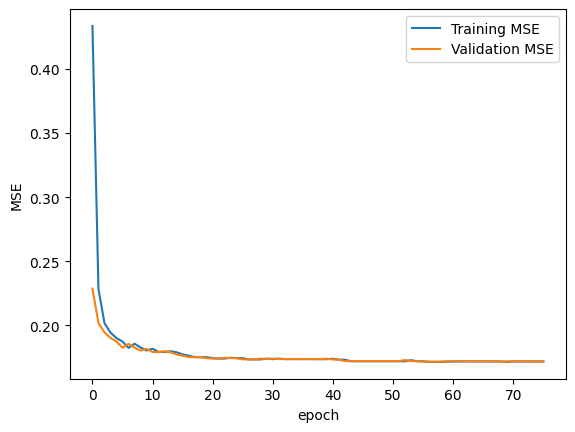

MSE Test: 0.17215013793431555


In [ ]:
# 5-layer ReLU autoencoder: the unique part is the deeper architecture and its parameter setup.
class Autoencoder:
    def __init__(self, input_size, hid1_size, hid2_size, hid3_size, hid4_size, hid5_size):
        self.input_size = input_size
        self.hid1_size = hid1_size
        self.hid2_size = hid2_size
        self.hid3_size = hid3_size
        self.hid4_size = hid4_size
        self.hid5_size = hid5_size

        self.w1 = np.random.randn(self.input_size, self.hid1_size)
        self.b1 = np.zeros((1, self.hid1_size))
        self.w2 = np.random.randn(self.hid1_size, self.hid2_size)
        self.b2 = np.zeros((1, self.hid2_size))
        self.w3 = np.random.randn(self.hid2_size, self.hid3_size)
        self.b3 = np.zeros((1, self.hid3_size))
        self.w4 = np.random.randn(self.hid3_size, self.hid4_size)
        self.b4 = np.zeros((1, self.hid4_size))
        self.w5 = np.random.randn(self.hid4_size, self.hid5_size)
        self.b5 = np.zeros((1, self.hid5_size))
        self.w6 = np.random.randn(self.hid5_size, self.input_size)
        self.b6 = np.zeros((1, self.input_size))

        self.epsilon = 1e-4
        self.tolerance = 20
        self.best_validation_loss = float('inf')
        self.tolerance_counter = 0

    def train(self, X, learning_rate, epoch, valid_data):
        mse_train_err = []
        mse_val_err = []

        for epoch in range(epoch):
            input_hid1_layer = np.dot(X, self.w1) + self.b1
            output_hid1_layer = relu(input_hid1_layer)
            input_hid2_layer = np.dot(output_hid1_layer, self.w2) + self.b2
            output_hid2_layer = relu(input_hid2_layer)
            input_hid3_layer = np.dot(output_hid2_layer, self.w3) + self.b3
            output_hid3_layer = relu(input_hid3_layer)
            input_hid4_layer = np.dot(output_hid3_layer, self.w4) + self.b4
            output_hid4_layer = relu(input_hid4_layer)
            input_hid5_layer = np.dot(output_hid4_layer, self.w5) + self.b5
            output_hid5_layer = relu(input_hid5_layer)
            output_layer_in = np.dot(output_hid5_layer, self.w6) + self.b6
            output_layer_out = relu(output_layer_in)

            loss = X - output_layer_out
            mse = np.mean(np.square(loss))
            mse_train_err.append(mse)

            d_output = loss * relu_derivative(output_layer_out)
            d_hid5_layer = d_output.dot(self.w6.T) * relu_derivative(output_hid5_layer)
            d_hid4_layer = d_hid5_layer.dot(self.w5.T) * relu_derivative(output_hid4_layer)
            d_hid3_layer = d_hid4_layer.dot(self.w4.T) * relu_derivative(output_hid3_layer)
            d_hid2_layer = d_hid3_layer.dot(self.w3.T) * relu_derivative(output_hid2_layer)
            d_hid1_layer = d_hid2_layer.dot(self.w2.T) * relu_derivative(output_hid1_layer)

            self.w6 += output_hid5_layer.T.dot(d_output) * learning_rate
            self.b6 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
            self.w5 += output_hid4_layer.T.dot(d_hid5_layer) * learning_rate
            self.b5 += np.sum(d_hid5_layer, axis=0, keepdims=True) * learning_rate
            self.w4 += output_hid3_layer.T.dot(d_hid4_layer) * learning_rate
            self.b4 += np.sum(d_hid4_layer, axis=0, keepdims=True) * learning_rate
            self.w3 += output_hid2_layer.T.dot(d_hid3_layer) * learning_rate
            self.b3 += np.sum(d_hid3_layer, axis=0, keepdims=True) * learning_rate
            self.w2 += output_hid1_layer.T.dot(d_hid2_layer) * learning_rate
            self.b2 += np.sum(d_hid2_layer, axis=0, keepdims=True) * learning_rate
            self.w1 += X.T.dot(d_hid1_layer) * learning_rate
            self.b1 += np.sum(d_hid1_layer, axis=0, keepdims=True) * learning_rate

            validation_loss = self.validate(valid_data)
            mse_val_err.append(validation_loss)

            if validation_loss < self.best_validation_loss - self.epsilon:
                self.best_validation_loss = validation_loss
                self.tolerance_counter = 0
            else:
                self.tolerance_counter += 1

            if self.tolerance_counter >= self.tolerance:
                print(f'\nThe model has reached convergence at epoch {epoch + 1}.')
                break

            print(f'Epoch {epoch + 1}/100, MSE: {mse}, Validation MSE: {validation_loss}')

        return mse_train_err, mse_val_err

    def validate(self, X):
        input_hid1_layer = np.dot(X, self.w1) + self.b1
        output_hid1_layer = relu(input_hid1_layer)
        input_hid2_layer = np.dot(output_hid1_layer, self.w2) + self.b2
        output_hid2_layer = relu(input_hid2_layer)
        input_hid3_layer = np.dot(output_hid2_layer, self.w3) + self.b3
        output_hid3_layer = relu(input_hid3_layer)
        input_hid4_layer = np.dot(output_hid3_layer, self.w4) + self.b4
        output_hid4_layer = relu(input_hid4_layer)
        input_hid5_layer = np.dot(output_hid4_layer, self.w5) + self.b5
        output_hid5_layer = relu(input_hid5_layer)
        output_layer_in = np.dot(output_hid5_layer, self.w6) + self.b6
        output_layer_out = relu(output_layer_in)
        loss = X - output_layer_out
        mse = np.mean(np.square(loss))
        return mse

input_size = 784
hid1_size = 256
hid2_size = 128
hid3_size = 64
hid4_size = 128
hid5_size = 256
learning_rate = 0.001
epoch = 100

autoencoder = Autoencoder(input_size, hid1_size, hid2_size, hid3_size, hid4_size, hid5_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data)

plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Experiment 5
This setup switches to ReLU activations while keeping the same overall architecture. It checks whether nonlinearity and sparsity improve reconstruction compared with sigmoid-based models.

Epoch 1/100, MSE: 1341.9366990616745, Validation MSE: 8815.987300987568
Epoch 2/100, MSE: 8500.260895417245, Validation MSE: 0.11248875500396237
Epoch 3/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 4/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 5/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 6/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 7/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 8/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 9/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 10/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 11/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 12/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 13/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 14/100, MSE: 0.11190

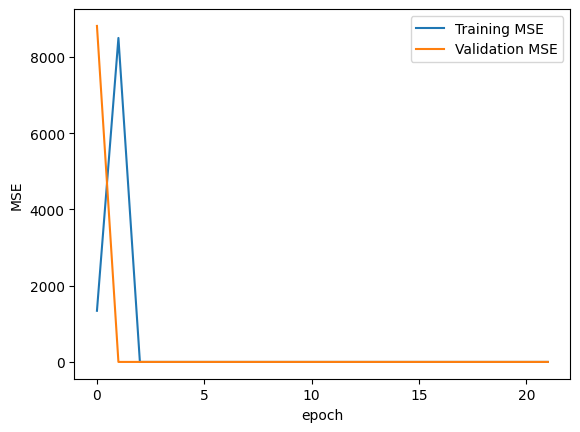

MSE Test: 0.11395810511655634


In [ ]:
# Reuse the shared ReLU autoencoder and only change the learning setup.
input_size = 784
hid_size = 64
learning_rate = 0.001
epoch = 100

autoencoder = Autoencoder(input_size, hid_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data)

plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Experiment 6
This version keeps the ReLU autoencoder architecture but reduces the learning rate to test sensitivity to optimization step size.

Epoch 1/100, MSE: 1834.7775269524388, Validation MSE: 3706.7538339513603
Epoch 2/100, MSE: 3667.0259547711153, Validation MSE: 117155.48906797716
Epoch 3/100, MSE: 115918.52950454119, Validation MSE: 0.11248875500396237
Epoch 4/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 5/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 6/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 7/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 8/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 9/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 10/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 11/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 12/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 13/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 14/100, MSE: 0.11190

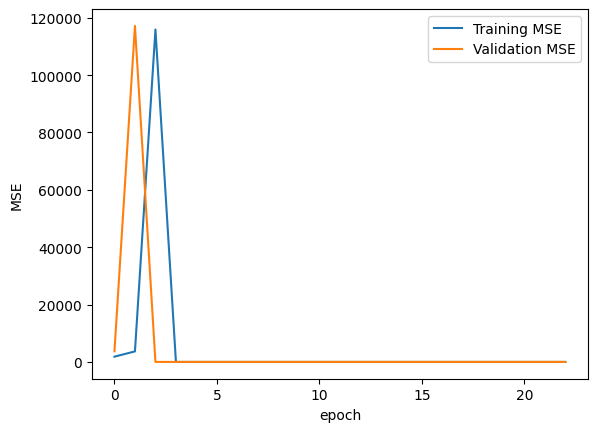

MSE Test: 0.11395810511655634


In [ ]:
# Reuse the shared ReLU autoencoder and only modify the learning rate to measure sensitivity.
input_size = 784
hid_size = 64
learning_rate = 0.000001
epoch = 100

autoencoder = Autoencoder(input_size, hid_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data)

plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Experiment 7
This setting uses a higher learning rate with ReLU to see whether faster updates improve convergence or instead lead to instability.

Epoch 1/100, MSE: 1391.9354610595049, Validation MSE: 0.11248875500396237
Epoch 2/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 3/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 4/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 5/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 6/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 7/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 8/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 9/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 10/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 11/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 12/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 13/100, MSE: 0.11190534362803944, Validation MSE: 0.11248875500396237
Epoch 14/100, MSE: 0.1

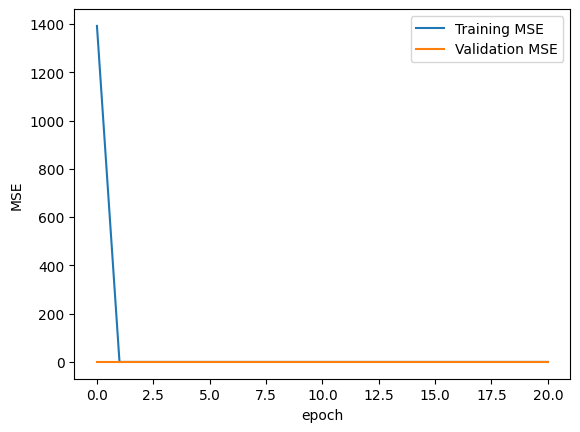

MSE Test: 0.11395810511655634


In [ ]:
# Reuse the shared ReLU autoencoder and only change the learning rate for the high-learning-rate variant.
input_size = 784
hid_size = 64
learning_rate = 0.01
epoch = 100

autoencoder = Autoencoder(input_size, hid_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data)

plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Experiment 8
This model applies mini-batch training with ReLU to evaluate the effect of batch updates on training stability and convergence speed.

Epoch 1/100, MSE: 0.07685817515355704, Validation MSE: 0.11222955466369199
Epoch 2/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 3/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 4/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 5/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 6/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 7/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 8/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 9/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 10/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 11/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 12/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 13/100, MSE: 0.0768581751536034, Validation MSE: 0.11222955466370525
Epoch 14/100, MSE: 0.076858175153

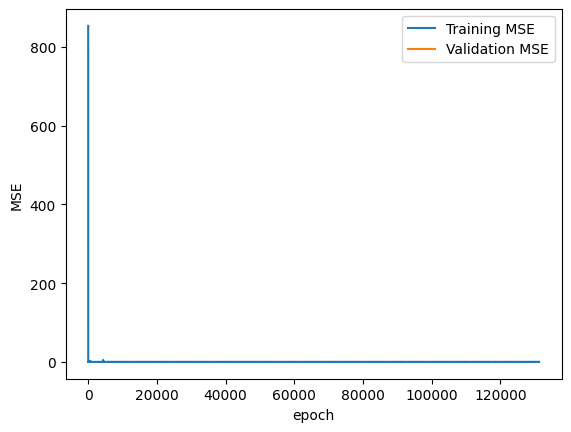

MSE Test: 0.12115670568838151


In [ ]:
# Reuse the shared ReLU autoencoder and only switch to mini-batch training.
input_size = 784
hid_size = 64
learning_rate = 0.001
epoch = 100
batch_size = 8

autoencoder = Autoencoder(input_size, hid_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data, batch_size=batch_size)

plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Experiment 9
This experiment uses a batch size of 8 and a tuned ReLU setup to compare training behavior under small-batch updates before selecting the best candidate.

# Best network

Epoch 1/100, MSE: 0.08995956902433111, Validation MSE: 0.11219033027777493
Epoch 2/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 3/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 4/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 5/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 6/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 7/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 8/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 9/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 10/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 11/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 12/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 13/100, MSE: 0.08995956597307525, Validation MSE: 0.11219032997271465
Epoch 14/100, MSE: 0.

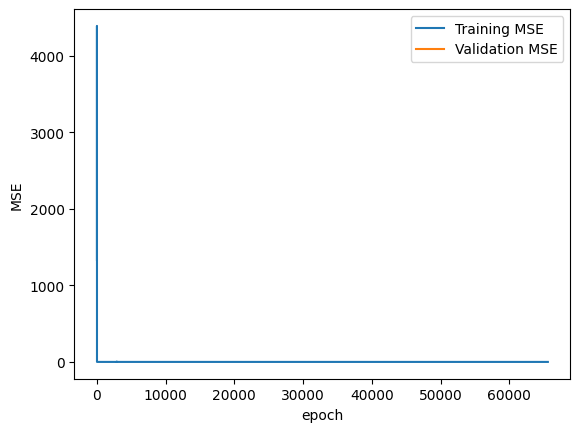

MSE Test: 0.11367649150485823


In [ ]:
# Reuse the same mini-batch ReLU setup and only adjust the batch size to compare training behavior.
input_size = 784
hid_size = 64
learning_rate = 0.001
epoch = 100
batch_size = 16

autoencoder = Autoencoder(input_size, hid_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data, batch_size=batch_size)

plt.plot(range(len(mse_train_err)), mse_train_err, label='Training MSE')
plt.plot(range(len(mse_val_err)), mse_val_err, label='Validation MSE')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

mse_test = autoencoder.validate(test_data)
print(f'MSE Test: {mse_test}')

## Final benchmark
This final run evaluates the selected mini-batch ReLU autoencoder on the full MNIST test set. It measures reconstruction quality and highlights both the best and worst examples to show where the model is strongest and where it still struggles.


MSE Test: 0.11395810511655634
Pics with most reconstruction error::
Pics with least reconstruction error::


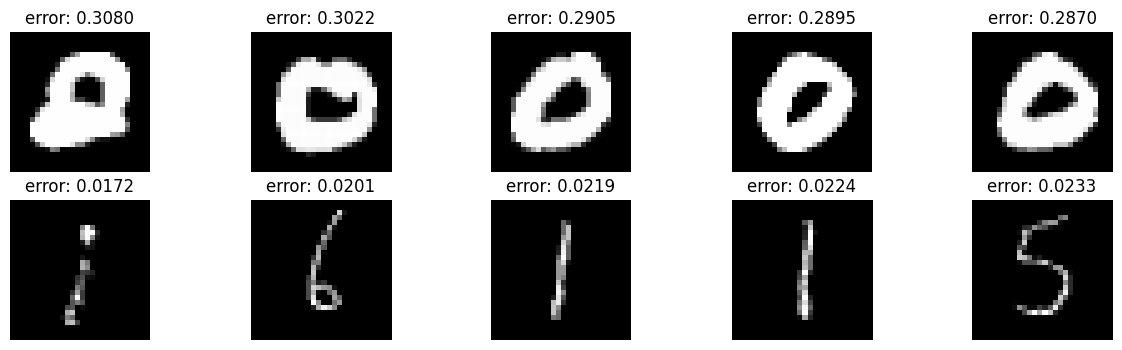

In [ ]:
# Final benchmark: reuse the selected mini-batch ReLU network and keep only the unique visualization logic.
input_size = 784
hid_size = 64
learning_rate = 0.001
epoch = 100
batch_size = 16

autoencoder = Autoencoder(input_size, hid_size)
mse_train_err, mse_val_err = autoencoder.train(train_data, learning_rate, epoch, valid_data, batch_size=batch_size)

num_images = 5
reconstruction_errors = [(i, autoencoder.validate(test_data[i:i+1])) for i in range(len(test_data))]
sorted_errors = sorted(reconstruction_errors, key=lambda x: x[1])

print("Images with highest reconstruction error:")
plt.figure(figsize=(15, 4))
for i in range(num_images):
    index, error = sorted_errors[-(i + 1)]
    image = test_data[index].reshape(28, 28)
    plt.subplot(2, num_images, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'error: {error:.4f}')
    plt.axis('off')

print("Images with lowest reconstruction error:")
for i in range(num_images):
    index, error = sorted_errors[i]
    image = test_data[index].reshape(28, 28)
    plt.subplot(2, num_images, num_images + i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'error: {error:.4f}')
    plt.axis('off')

plt.show()